In [1]:
# install libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns



from datetime import datetime
from pathlib import Path
from collections import defaultdict




In [2]:
# load AMI files

current_path = Path(os.getcwd())
ami_folder = current_path / '..'/ 'NREL'

ind_load_csv = ami_folder / 'consumption'/ 'ch1_4301002_individual.csv'
location_ref = ami_folder / 'location_reference.csv'
agg_load_csv = ami_folder / 'consumption'/ 'ch1_4301002_aggregated.csv'
print('done')

done


In [17]:
# read csv and plot graphs

df = pd.read_csv(ind_load_csv)
df.head()

#Summer – April to October 
#Winter – Jan to Mar, Nov to Dec 



# Convert 'ENDTIME_EST' to datetime
df['ENDTIME_EST'] = pd.to_datetime(df['ENDTIME_EST'])
# Filter for dates from Jan 1 to Dec 31, 2024
df_2024 = df[(df['ENDTIME_EST'] >= '2024-01-01') & (df['ENDTIME_EST'] < '2025-01-01')]
# Filter for summer dates April to October
df_2024_summer = df[(df['ENDTIME_EST'] >= '2024-04-01') & (df['ENDTIME_EST'] < '2024-09-30')]
# Filter for winter dates Jan to March, Nov to Dec
df_2024_winter = df[
    ((df['ENDTIME_EST'] >= '2024-01-01') & (df['ENDTIME_EST'] < '2024-04-1')) | 
    ((df['ENDTIME_EST'] >= '2024-11-01') & (df['ENDTIME_EST'] < '2025-01-01'))
]

print("Max INTERVAL_READ:", df_2024['INTERVAL_READ'].max())
# Max INTERVAL_READ: 48.96
print("Max INTERVAL_READ summer:", df_2024_summer['INTERVAL_READ'].max())

print("Number of unique SERVICEPOINTID:", df_2024['SERVICEPOINTID'].nunique())


print(df_2024['INTERVAL_READ'].describe())
print("\nTop 10 highest INTERVAL_READ values:")
print(df_2024.sort_values('INTERVAL_READ', ascending=False).head(10))



print('done')


Max INTERVAL_READ: 48.96
Max INTERVAL_READ summer: 47.28
Number of unique SERVICEPOINTID: 670
count    2.138023e+07
mean     3.236023e-01
std      1.164701e+00
min      0.000000e+00
25%      5.600000e-02
50%      1.310000e-01
75%      2.880000e-01
max      4.896000e+01
Name: INTERVAL_READ, dtype: float64

Top 10 highest INTERVAL_READ values:
          SERVICEPOINTID  CHANNELNUMBER         ENDTIME_EST  INTERVAL_READ
13119859      6000984488              1 2024-05-22 11:30:00          48.96
13119866      6000984488              1 2024-05-22 13:15:00          48.96
13119860      6000984488              1 2024-05-22 11:45:00          48.48
13119863      6000984488              1 2024-05-22 12:30:00          48.48
13119869      6000984488              1 2024-05-22 14:00:00          48.48
13119865      6000984488              1 2024-05-22 13:00:00          47.76
13119856      6000984488              1 2024-05-22 10:45:00          47.52
13119870      6000984488              1 2024-05-22 14:15

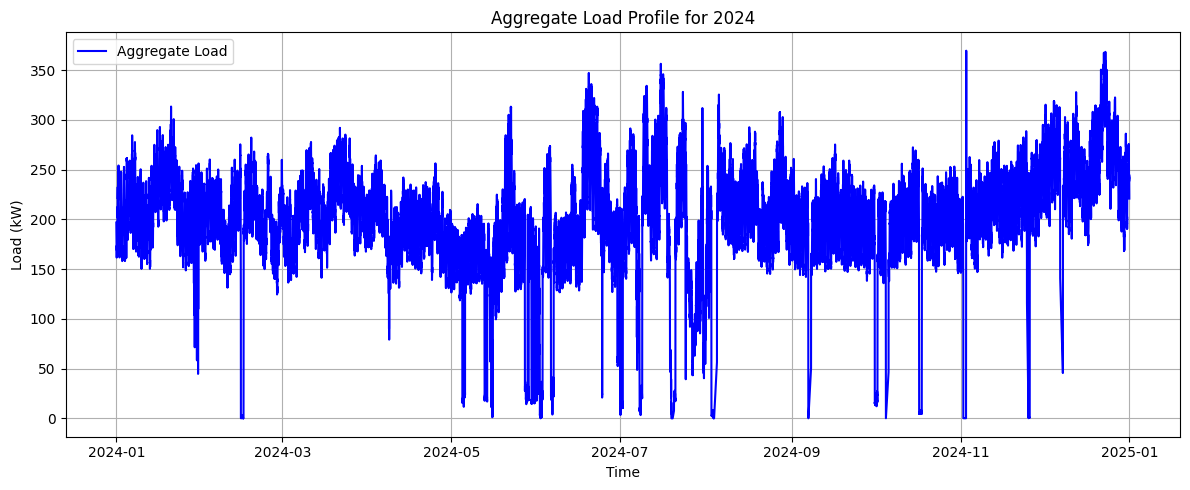

In [7]:


# Read aggregate CSV
df_agg = pd.read_csv(agg_load_csv)
df_agg.head()

# Convert 'ENDTIME_EST' to datetime
df_agg['ENDTIME_EST'] = pd.to_datetime(df_agg['ENDTIME_EST'])

# Filter for dates from Jan 1 to Dec 31, 2024
df_2024 = df_agg[(df_agg['ENDTIME_EST'] >= '2024-01-01') & (df_agg['ENDTIME_EST'] < '2025-01-01')]

# Filter for summer dates June - September
df_2024_summer = df_agg[(df_agg['ENDTIME_EST'] >= '2024-06-01') & (df_agg['ENDTIME_EST'] < '2024-09-30')]

# Filter for winter dates Jan – May, Oct-Dec
df_2024_winter = df_agg[
    ((df_agg['ENDTIME_EST'] >= '2024-01-01') & (df_agg['ENDTIME_EST'] < '2024-05-31')) | 
    ((df_agg['ENDTIME_EST'] >= '2024-10-01') & (df_agg['ENDTIME_EST'] < '2025-01-01'))
]

# Plot aggregate load profile for 2024
plt.figure(figsize=(12, 5))
plt.plot(df_2024['ENDTIME_EST'], df_2024['CONSUMPTION'], label='Aggregate Load', color='blue')
plt.xlabel('Time')
plt.ylabel('Load (kW)')
plt.title('ch1_4301002_aggregated')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Calculate Coincident Peak
df = pd.read_csv(ind_load_csv)

# Convert 'ENDTIME_EST' to datetime
df['ENDTIME_EST'] = pd.to_datetime(df['ENDTIME_EST'])
# Filter for dates from Jan 1 to Dec 31, 2024
df_2024 = df[(df['ENDTIME_EST'] >= '2024-01-01') & (df['ENDTIME_EST'] < '2025-01-01')]

print("Number of unique SERVICEPOINTID:", df_2024['SERVICEPOINTID'].nunique())

# Group by timestamp and sum INTERVAL_READ across all SERVICEPOINTIDs
aggregated_profile = df_2024.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

# Rename column for clarity
aggregated_profile = aggregated_profile.rename(columns={'INTERVAL_READ': 'AGGREGATE_LOAD_KW'})

# Find peak load and corresponding timestamp
peak_row = aggregated_profile.loc[aggregated_profile['AGGREGATE_LOAD_KW'].idxmax()]
peak_load = peak_row['AGGREGATE_LOAD_KW']
peak_time = peak_row['ENDTIME_EST']

print(f"Coincident Peak Load: {peak_load:.2f} kW at {peak_time}")

# Calculate non coincident peak
non_coincident_peaks = df_2024.groupby('SERVICEPOINTID')['INTERVAL_READ'].max()
                                       
non_coincident_peak_load = non_coincident_peaks.sum()
print(f"Non Coincident Peak Load: {non_coincident_peak_load} kW")


Number of unique SERVICEPOINTID: 670
Coincident Peak Load: 369.60 kW at 2024-11-03 01:30:00
Non Coincident Peak Load: 1463.2980000000002 kW


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(aggregated_profile['ENDTIME_EST'], aggregated_profile['AGGREGATE_LOAD_KW'], label='Aggregate Load')
plt.xlabel('Time')
plt.ylabel('Load (kW)')
plt.title('Aggregate Load Profile for 2024')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14, 6))

for sp_id in df_2024['SERVICEPOINTID'].unique():
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
    plt.plot(sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'], label=f'SP {sp_id}', linewidth=0.8)

# Format x-axis to show month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels and layout
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title('Raw Interval Read (Jan–Dec 2024) by ServicePointID')
#plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small', ncol=1)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# read location reference


location_df = pd.read_csv(location_ref, dtype={'xfr_gisid': str, 'servicepointid': str})
location_df.head()

In [ ]:
# service point id 

#node_id = ['220270493', '220270494', '220270496']

# Clean or standardize customer type column if needed
location_df['Residential'] = location_df['Residential'].str.strip()  # remove whitespace
location_df['Residential'] = location_df['Residential'].fillna('Unknown')  # handle NaNs

# Initialize nested defaultdict
nested_dict = defaultdict(lambda: defaultdict(list))

for _, row in location_df.iterrows():
    node_id = row['xfr_gisid']
    cust_type = row['Residential']
    servicepoint_id = row['servicepointid']
    nested_dict[node_id][cust_type].append(servicepoint_id)

# --- Step 3: Helper function to access servicepointids easily ---
def get_service_ids_by_type(load_id_dict, nested_dict, type_key='res'):
    """
    Given a load_id dictionary (e.g., {'res': '220603575'}),
    return list of servicepointids for that type (res or comm).
    """
    node_id = load_id_dict.get(type_key)
    if not node_id:
        return []
    # Capitalize 'res' → 'Res', 'comm' → 'Comm'
    cust_type = type_key.capitalize()
    return nested_dict.get(node_id, {}).get(cust_type, [])


print('done')

In [ ]:
# LOAD ID 1


load_id = {'res': '220269965'}
service_ids = get_service_ids_by_type(load_id, nested_dict, 'res')
print(f"Residential servicepoint IDs for node {load_id['res']}: {service_ids}")

#### LOAD ID 1
#### FULL YEAR
#### INDIVIDUAL

In [ ]:
# LOAD ID 1
# FULL YEAR
# INDIVIDUAL

plt.figure(figsize=(14, 6))
df_2024 = df_2024.copy()
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)


# Define colors and styles for each line
#supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
linestyles = ['-', '-.', '--']
linewidths = [0.7, 0.6, 0.4]
#alpha=0.5 if i == 2 else 1.0
alphas = [1.0, 0.6, 0.6]
colors = sns.color_palette("muted", n_colors=len(service_ids))  # or "colorblind", "muted", "deep"

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
#    if not sp_data.empty:
#        plt.plot(sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'], label=f'SP {sp_id}', linewidth=0.8)

    if not sp_data.empty:
        plt.plot(sp_data['ENDTIME_EST'], 
                 sp_data['INTERVAL_READ'], 
                 color = colors[i],
                 linestyle = linestyles[i % 3],
                 linewidth = linewidths[i % 3],
                 alpha = alphas[i % 3],
                 label=f'SP {sp_id}')

# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))
plt.ylim(0, 5.5)

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
plt.axhline(y=4.915, color='blue', linestyle=':', linewidth=0.8, label='Winter Coincident Peak (4.92 kW)')


# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Interval Read for Node {load_id["res"]}')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='large')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Interval Read for Node.png', dpi=300, bbox_inches='tight')
plt.show()

#### LOAD ID 1
#### FULL YEAR
#### AGGREGATE

In [ ]:
# LOAD ID 1
#FULL YEAR
# AGGREGATE
df_2024 = df_2024.copy()

# Make sure SERVICEPOINTID is string
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024[df_2024['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kWh)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['INTERVAL_READ'], label='kW', color='blue', linewidth=0.5, alpha = 0.9)

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
plt.axhline(y=4.915, color='blue', linestyle=':', linewidth=0.8, label='Winter Coincident Peak (4.92 kW)')


# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))
plt.ylim(0, 5.5)

# Labels
plt.xlabel('Month', fontsize=14)
plt.ylabel('Aggregated Power (kW)', fontsize=14)
plt.title(f'Aggregated Power for 3 Residential Buildings at Node {load_id["res"]}', fontsize=16)
plt.grid(True)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.20),  # Bottom left outside the plot
    fontsize='large',
    frameon=True,
    ncol=1
)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('Aggregate Power for Node.png', dpi=600, bbox_inches='tight')  # Increased to 600 dpi for even higher quality

plt.show()



In [ ]:
# LOAD ID 1
# SUMMER 
# INDIVIDUAL

plt.figure(figsize=(14, 6))
df_2024_summer = df_2024_summer.copy()
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)


# Define colors and styles for each line
linestyles = ['-', '-.', '-']
linewidths = [0.7, 0.6, 0.7]

colors = sns.color_palette("muted", n_colors=len(service_ids))  # or "colorblind", "muted", "deep"

non_coinc_peak_sum = 0
non_coinc_peaks_by_id = {}

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024_summer[df_2024_summer['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        # Get individual peak
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        peak_value = non_coinc_peak['INTERVAL_READ']
        non_coinc_peaks_by_id[sp_id] = peak_value
        non_coinc_peak_sum += peak_value

        # Plot line only (no peak markers)
        plt.plot(
            sp_data['ENDTIME_EST'], 
            sp_data['INTERVAL_READ'], 
            color=colors[i],
            linestyle=linestyles[i % 3],
            linewidth=linewidths[i % 3],
            label=f'SP {sp_id}'
        )

# ---- Print individual peaks ----
print("Individual Non-Coincident Peaks:")
for sp_id, peak_val in non_coinc_peaks_by_id.items():
    print(f"  - SP {sp_id}: {peak_val:.3f} kW")

# ---- Print total ----
print(f"\nTotal Non-Coincident Peak Load: {non_coinc_peak_sum:.3f} kW")

# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-09-30'))
plt.ylim(0, 3.5)

# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Interval Read for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# LOAD ID 1
# SUMMER 

# Make sure SERVICEPOINTID is string
df_2024_summer = df_2024_summer.copy()

## CALCULATE AGGREGATE PEAK FOR ENTIRE FEEDER
agg_df_feeder = df_2024_summer.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()
coinc_peak_row_feeder = agg_df_feeder.loc[agg_df_feeder['INTERVAL_READ'].idxmax()]
coinc_peak_value_feeder = coinc_peak_row_feeder['INTERVAL_READ']
coinc_peak_time_feeder = coinc_peak_row_feeder['ENDTIME_EST']

print(f"Summer Coincident peak for entire feeder: {coinc_peak_value_feeder} kW. Time: {coinc_peak_time_feeder}")

#### CALCULATE PEAK SUMMER LOAD FOR FEEDER NODE 
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024_summer[df_2024_summer['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kW)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

#################################
# CHECKS: 

# print(f"Original total: {filtered_df['INTERVAL_READ'].sum()}")
# print(f"Aggregated total: {agg_df['INTERVAL_READ'].sum()}")

# # Pick a timestamp from the aggregated result
# test_timestamp = agg_df['ENDTIME_EST'].iloc[0]

# # Manually sum INTERVAL_READ values for that timestamp in the filtered_df
# manual_sum = filtered_df[filtered_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].sum()

# # Compare it to the aggregated value
# agg_sum = agg_df[agg_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].values[0]

# print(f"Manual sum: {manual_sum}, Aggregated sum: {agg_sum}")
#################################

## CALCULATE PEAK SUMMER LOAD

# Coincident aggregated peak

# Find the row with the maximum load
coinc_peak_row = agg_df.loc[agg_df['INTERVAL_READ'].idxmax()]

print(f"Coincident peak: {coinc_peak_row['INTERVAL_READ']} kW. Time: {coinc_peak_row['ENDTIME_EST']}")



# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['INTERVAL_READ'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-09-30'))

# Labels
plt.xlabel('Month')
plt.ylabel('Aggregated Power (kW)')
plt.title(f'Aggregated Power for Summer at Node {load_id["res"]}')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
## SUMMER SINGLE DAY PEAK
## AGGREGATE LOAD

# Make sure SERVICEPOINTID is string
df_2024_summer = df_2024_summer.copy()
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024_summer[df_2024_summer['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kW)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()


## CALCULATE PEAK SUMMER LOAD

# Coincident aggregated peak

# Find the row with the maximum load
coinc_peak_row = agg_df.loc[agg_df['INTERVAL_READ'].idxmax()]

print(f"Coincident peak: {coinc_peak_row['INTERVAL_READ']} kW. Time: {coinc_peak_row['ENDTIME_EST']}")

coinc_peak_time = coinc_peak_row['ENDTIME_EST']
coinc_peak_value = coinc_peak_row['INTERVAL_READ']

peak_day = coinc_peak_time.date()

peak_day_data = agg_df[agg_df['ENDTIME_EST'].dt.date == peak_day]

# Plot the 24-hour load profile of the peak day
plt.figure(figsize=(14, 6))
plt.plot(peak_day_data['ENDTIME_EST'], peak_day_data['INTERVAL_READ'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(peak_day_data['ENDTIME_EST'].min(), peak_day_data['ENDTIME_EST'].max())

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
# Add non coincident peak lines (horizontal)
plt.axhline(y=8.64, color='darkred', linestyle='--', linewidth=0.8, label='Summer Non-Coincident Peak (8.64 kW)')
            
# Labels
plt.xlabel('Hour of Day',fontsize=14 )
plt.ylabel('Aggregated Power (kW)',fontsize=14)
plt.title(f'Aggregate Power (3 buildings) for Peak Summer Day {peak_day}', fontsize=16)
plt.grid(True)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.20),  # Bottom left outside the plot
    fontsize='large',
    frameon=True,
    ncol=1
)
plt.xticks(rotation=45, fontsize='14')
plt.yticks(fontsize='14')
plt.tight_layout()

plt.savefig('Aggregate Power for summer single day.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# LOAD ID 1
# SUMMER DAY PEAK
# INDIVIDUAL


from datetime import datetime

plt.figure(figsize=(14, 6))

# Ensure SERVICEPOINTID is string
df_2024_summer = df_2024_summer.copy()
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)

# Define styles
linestyles = ['-', '-', '-']
linewidths = [1, 1, 1]
colors = sns.color_palette("dark", n_colors=len(service_ids))


# Set coincident peak day
coinc_peak_day = pd.to_datetime("2024-06-10").date()

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024_summer[df_2024_summer['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:

        # Filter data for coincident peak day
        coinc_peak_data = sp_data[sp_data['ENDTIME_EST'].dt.date == coinc_peak_day]

        # Plot line only
        plt.plot(
            coinc_peak_data['ENDTIME_EST'],
            coinc_peak_data['INTERVAL_READ'],
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=linewidths[i % len(linewidths)],
            label=f'SP {sp_id}'
        )

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(peak_day_data['ENDTIME_EST'].min(), peak_day_data['ENDTIME_EST'].max())

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
# Add non coincident peak lines (horizontal)
plt.axhline(y=8.64, color='darkred', linestyle='--', linewidth=0.8, label='Summer Non-Coincident Peak (8.64 kW)')


# Labels and formatting with larger fonts
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Power (kW)", fontsize=14)
plt.title("Individual Power Demand Profiles for Peak Summer Day (2024-06-10)", fontsize=16)
plt.grid(True)

# Legend at bottom left
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.20),
    fontsize='large',
    frameon=True,
    ncol=1
)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig('Load Profiles on Coincident Summer Peak Day (2024-06-10).png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# # LOAD ID 1
# # WINTER 
## INDIVIDUAL LOADS

non_coinc_peak_sum = 0
non_coinc_peaks_by_id = {}

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024_winter[df_2024_winter['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        peak_value = non_coinc_peak['INTERVAL_READ']
        non_coinc_peaks_by_id[sp_id] = peak_value
        non_coinc_peak_sum += peak_value

# ---- Print individual peaks ----
print("Winter Non-Coincident Peaks:")
for sp_id, peak_val in non_coinc_peaks_by_id.items():
    print(f"  - SP {sp_id}: {peak_val:.3f} kW")

# ---- Print total ----
print(f"\nTotal Winter Non-Coincident Peak Load: {non_coinc_peak_sum:.3f} kW")


# Split winter data into two seasonal subsets
df_jan_jun = df_2024_winter[(df_2024_winter['ENDTIME_EST'] >= '2024-01-01') & 
                            (df_2024_winter['ENDTIME_EST'] < '2024-07-01')]

df_oct_dec = df_2024_winter[(df_2024_winter['ENDTIME_EST'] >= '2024-10-01') & 
                            (df_2024_winter['ENDTIME_EST'] < '2025-01-01')]

# Define colors and styles
linestyles = ['-', '-.', '--']
linewidths = [0.7, 0.6, 0.4]
#alpha=0.5 if i == 2 else 1.0
alphas = [1.0, 0.6, 0.6]
colors = sns.color_palette("muted", n_colors=len(service_ids))

# ---------- Jan–Jun Plot ----------
plt.figure(figsize=(14, 6))

for i, sp_id in enumerate(service_ids):
    sp_data = df_jan_jun[df_jan_jun['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        non_coinc_peak_sum_jan_jun += non_coinc_peak['INTERVAL_READ']

        plt.plot(
            sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'],
            color=colors[i],
            linestyle=linestyles[i % 3],
            linewidth=linewidths[i % 3],
            alpha = alphas[i%3],
            label=f'SP {sp_id}'
        )

plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2024-06-01'))
plt.ylim(0, 5.0)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Winter Load (Jan–Jun) for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### Oct–Dec Plot ----------
plt.figure(figsize=(14, 6))

for i, sp_id in enumerate(service_ids):
    sp_data = df_oct_dec[df_oct_dec['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        non_coinc_peak_sum_oct_dec += non_coinc_peak['INTERVAL_READ']

        plt.plot(
            sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'],
            color=colors[i],
            linestyle=linestyles[i % 3],
            linewidth=linewidths[i % 3],
            label=f'SP {sp_id}'
        )
# plt.xlim(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-01-01'))
# plt.ylim(0, 5.0)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Winter Load (Oct–Dec) for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# LOAD ID 1
# WINTER
## AGGREGATED

df_2024_winter = df_2024_winter.copy()

## CALCULATE AGGREGATE WINTER PEAK FOR ENTIRE FEEDER
agg_df_feeder = df_2024_winter.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()
coinc_peak_row_feeder = agg_df_feeder.loc[agg_df_feeder['INTERVAL_READ'].idxmax()]
coinc_peak_value_feeder = coinc_peak_row_feeder['INTERVAL_READ']
coinc_peak_time_feeder = coinc_peak_row_feeder['ENDTIME_EST']

print(f"Winter Coincident peak for entire feeder: {coinc_peak_value_feeder} kW. Time: {coinc_peak_time_feeder}")


### PEAK WINTER LOAD FOR FEEDER NODE
# Make sure SERVICEPOINTID is string

df_2024_winter['SERVICEPOINTID'] = df_2024_winter['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024_winter[df_2024_winter['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kW)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

## CALCULATE PEAK WINTER LOAD
# Coincident aggregated peak

# Find the row with the maximum load
coinc_peak_row = agg_df.loc[agg_df['INTERVAL_READ'].idxmax()]

print(f"Coincident peak: {coinc_peak_row['INTERVAL_READ']} kW. Time: {coinc_peak_row['ENDTIME_EST']}")

# #################################
# # CHECKS: 

# print(f"Original total: {filtered_df['INTERVAL_READ'].sum()}")
# print(f"Aggregated total: {agg_df['INTERVAL_READ'].sum()}")

# # Pick a timestamp from the aggregated result
# test_timestamp = agg_df['ENDTIME_EST'].iloc[0]

# # Manually sum INTERVAL_READ values for that timestamp in the filtered_df
# manual_sum = filtered_df[filtered_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].sum()

# # Compare it to the aggregated value
# agg_sum = agg_df[agg_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].values[0]

# print(f"Manual sum: {manual_sum}, Aggregated sum: {agg_sum}")
# #################################



# Plot kW

# Split aggregated data
agg_jan_jun = agg_df[(agg_df['ENDTIME_EST'] >= '2024-01-01') & (agg_df['ENDTIME_EST'] < '2024-07-01')]
agg_oct_dec = agg_df[(agg_df['ENDTIME_EST'] >= '2024-10-01') & (agg_df['ENDTIME_EST'] < '2025-01-01')]

# ---- Plot Jan–Jun ----
plt.figure(figsize=(14, 5))
plt.plot(agg_jan_jun['ENDTIME_EST'], agg_jan_jun['INTERVAL_READ'], color='steelblue', linewidth=2)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title('Aggregated Load (Jan–Jun)')
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2024-06-01'))
plt.ylim(0, 5.0)
plt.show()

# ---- Plot Oct–Dec ----
plt.figure(figsize=(14, 5))
plt.plot(agg_oct_dec['ENDTIME_EST'], agg_oct_dec['INTERVAL_READ'], color='darkorange', linewidth=2)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title('Aggregated Load (Oct–Dec)')
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-01-01'))
plt.ylim(0, 5.0)
plt.show()
